In [1]:
import os
os.chdir('../../../../../..')

In [2]:
import numpy as np
import polars as pl

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN
from umap import UMAP

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection,benchmark_functional_groups, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster,evaluate_hdbscan_grid

projection_method = "UMAP"

In [3]:
qm9 = QM9Dataset(limit=None, descriptors=["morgan"])
df = qm9.load()
X = np.array(df["morgan_fingerprint"].to_list())

2026-05-19 10:28:58.798 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-19 10:28:59.334 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=124232, sampling on columns=['num_atoms', 'gap'].
2026-05-19 10:28:59.347 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=124232).
2026-05-19 10:28:59.348 | INFO     | src.features:compute_morgan_fingerprints:225 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-05-19 10:32:57.255 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['morgan_fingerprint']


# Hypothesis 1
- Can destiniush between aromatic, cyclic and acyclic

In [4]:
df['structure_class'].value_counts()

structure_class,count
str,u32
"""Acyclic""",13390
"""Aliphatic Ring""",89912
"""Aromatic""",20930


In [5]:
# choose 100 of each structure type
df_acyclic = df.filter(pl.col("structure_class") == "Acyclic").sample(n=100, seed=42)
df_aromatic = df.filter(pl.col("structure_class") == "Aromatic").sample(n=100, seed=42)
df_rings = df.filter(pl.col("structure_class") == "Aliphatic Ring").sample(n=100, seed=42)
df_sample = pl.concat([df_acyclic, df_aromatic, df_rings])

# calculate distance matrix for the sample using Jaccard distance
from sklearn.metrics import pairwise_distances
# labels are 1 for aromatic, 2 for aliphatic ring, and 0 for acyclic use polars
labels = [1 if x == "Aromatic" else (2 if x == "Aliphatic Ring" else 0) for x in df_sample["structure_class"].to_list()]

dist_matrix = pairwise_distances(np.array(df_sample["morgan_fingerprint"].to_list()), metric="jaccard")

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


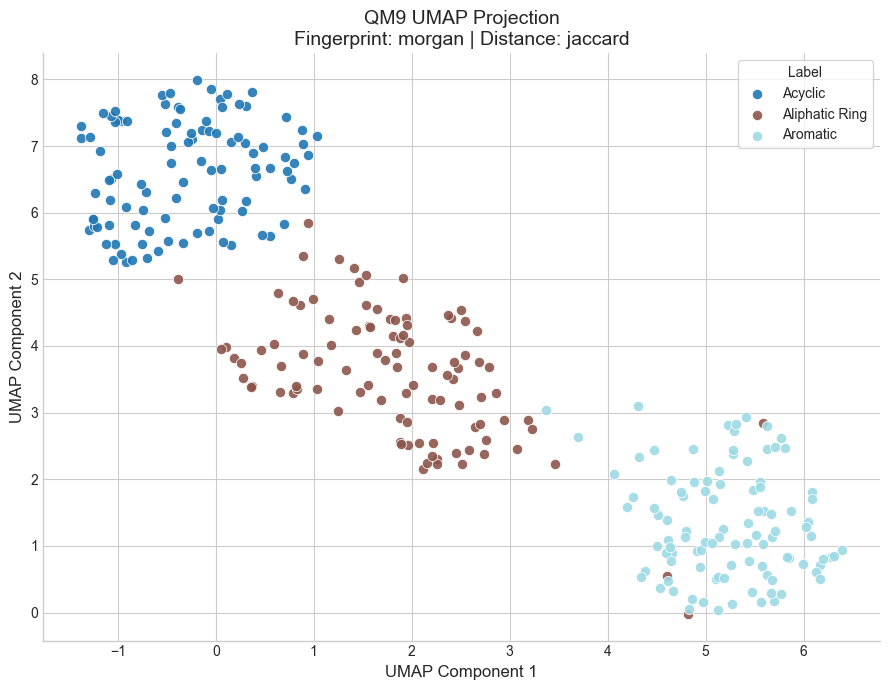

2026-05-19 10:34:29.981 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:628 - Saved UMAP projection plot to figures/qm9/clustering/jaccard/morgan/umap_projection.png


In [6]:
_=plot_distance_matrix_projection(dist_matrix, fingerprint="morgan", projection_method='UMAP', labels=df_sample["structure_class"].to_list(), distance_metric="jaccard")

ARI Score for Agglomerative Clustering: 0.9220
ARI Score for K-Medoids Clustering: 0.4637


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden t

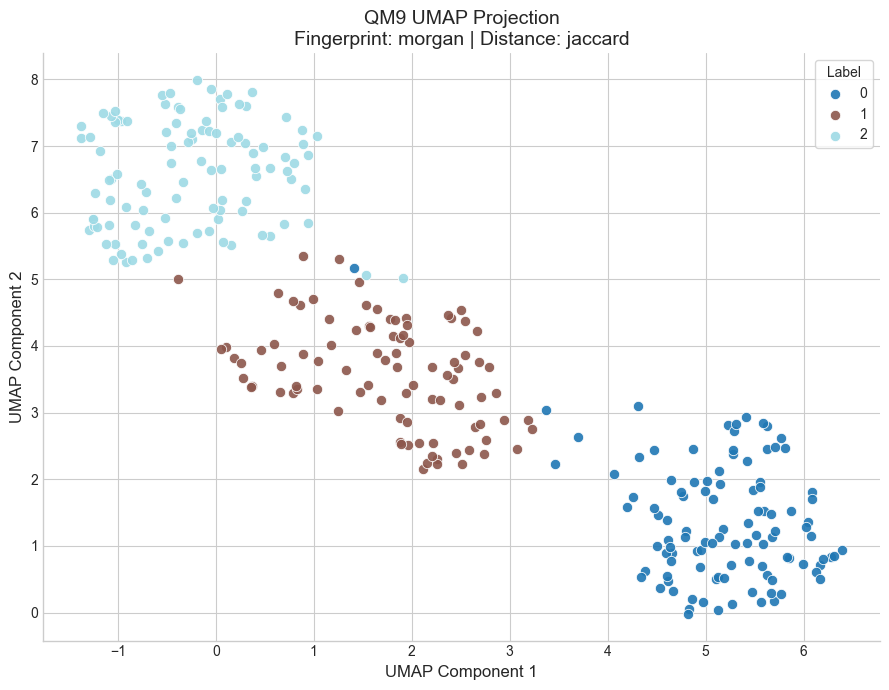

2026-05-19 10:34:58.660 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:628 - Saved UMAP projection plot to figures/qm9/clustering/jaccard/morgan/umap_projection.png


In [7]:
# agg clustering will be able to find the clusters, but it will not be perfect because of the noise in the data
agg_clust = AgglomerativeClustering(n_clusters=3, metric='precomputed', linkage='average')
predicted_labels = agg_clust.fit_predict(dist_matrix)
from sklearn.metrics import adjusted_rand_score
ari_score = adjusted_rand_score(labels, predicted_labels)
print(f"ARI Score for Agglomerative Clustering: {ari_score:.4f}")

kmedoids_clust = KMedoids(n_clusters=3, metric='precomputed', random_state=42)
predicted_labels_kmedoids = kmedoids_clust.fit_predict(dist_matrix)
ari_score_kmedoids = adjusted_rand_score(labels, predicted_labels_kmedoids)
print(f"ARI Score for K-Medoids Clustering: {ari_score_kmedoids:.4f}")

# plot the UMAP projection of the distance matrix
coords = UMAP(metric='precomputed', random_state=42).fit_transform(dist_matrix)
_=plot_distance_matrix_projection(dist_matrix, fingerprint="morgan", projection_method='UMAP', labels=predicted_labels, distance_metric="jaccard")

In [10]:
create_chemiscope_viewer(df_sample, dist_matrix, predicted_labels, 'UMAP')

2026-05-19 10:38:54.908 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-19 10:38:54.910 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-19 10:38:56.079 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 15
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-19 10:38:56.322 | INFO     | src.helper_

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

# Hyphotesis 2

In [26]:
fg_cols = [
    "fr_alcohol", "fr_phenol", "fr_amine", "fr_amide", 
    "fr_carboxylic_acid", "fr_ester", "fr_ketone", "fr_ether", "fr_nitro"
]

# 1. Define exact conditions for "Pure" Substitutions
# The sum of all OTHER functional groups must be 0 to ensure no mixed molecules (e.g., no fluoro-alcohols)

oh_cols = ["fr_alcohol", "fr_phenol"]
other_oh = [c for c in fg_cols if c not in oh_cols]

cond_oh = (
    (pl.col("fr_alcohol") + pl.col("fr_phenol") > 0) & 
    (pl.sum_horizontal(other_oh) == 0) & 
    (pl.col("num_fluorine") == 0)
)

cond_nh2 = (
    (pl.col("fr_amine") > 0) & 
    (pl.sum_horizontal([c for c in fg_cols if c != "fr_amine"]) == 0) & 
    (pl.col("num_fluorine") == 0)
)

cond_f = (
    (pl.col("num_fluorine") > 0) & 
    (pl.sum_horizontal(fg_cols) == 0)
)

# 2. Extract the three pure datasets
df_oh = df.filter(cond_oh).with_columns(pl.lit("Hydroxyl").alias("target_group"))
df_nh2 = df.filter(cond_nh2).with_columns(pl.lit("Amino").alias("target_group"))
df_f = df.filter(cond_f).with_columns(pl.lit("Fluoro").alias("target_group"))

# 3. Find the Scaffolds that exist in ALL THREE groups
# This is critical for the hypothesis: the base carbon topology must be the same!
scaffolds_oh = set(df_oh["scaffold_smiles"].to_list())
scaffolds_nh2 = set(df_nh2["scaffold_smiles"].to_list())
scaffolds_f = set(df_f["scaffold_smiles"].to_list())

# Intersect the sets to find common carbon skeletons
shared_scaffolds = list(scaffolds_oh & scaffolds_nh2 & scaffolds_f)

print(f"Found {len(shared_scaffolds)} scaffolds that have pure OH, NH2, and F derivatives.")

# 4. Filter the datasets down to ONLY the shared scaffolds
df_oh_final = df_oh.filter(pl.col("scaffold_smiles").is_in(shared_scaffolds))
df_nh2_final = df_nh2.filter(pl.col("scaffold_smiles").is_in(shared_scaffolds))
df_f_final = df_f.filter(pl.col("scaffold_smiles").is_in(shared_scaffolds))

# 5. Combine them for your UMAP experiment
df_experiment = pl.concat([df_oh_final, df_nh2_final, df_f_final])
df_experiment = df_experiment.filter(pl.col("structure_class") == "Acyclic")

Found 102 scaffolds that have pure OH, NH2, and F derivatives.


In [37]:
import random

# 1. Check if we have enough shared scaffolds (we need at least 100)
# (shared_scaffolds is the list we generated in the previous step)
num_scaffolds_to_sample = min(100, len(shared_scaffolds))

if len(shared_scaffolds) < 100:
    print(f"Warning: Only found {len(shared_scaffolds)} perfectly shared scaffolds. Using all of them.")

# Set a seed for reproducibility in your thesis
random.seed(42)
sampled_scaffolds = random.sample(list(shared_scaffolds), num_scaffolds_to_sample)

# 2. Extract exactly ONE molecule per sampled scaffold for each group.
# We use group_by and sample(1) because a scaffold might have multiple valid 
# positional isomers (e.g., 2-fluorohexane and 3-fluorohexane). We just need one.

# Sample the Hydroxyl group
df_oh_100 = (
    df_oh_final
    .filter(pl.col("scaffold_smiles").is_in(sampled_scaffolds))
    .group_by("scaffold_smiles")
    .agg(pl.all().sample(n=1, seed=42)) # Pick exactly 1 isomer per scaffold
    .explode(pl.all().exclude("scaffold_smiles")) # Flatten back to normal rows
)

# Sample the Amino group
df_nh2_100 = (
    df_nh2_final
    .filter(pl.col("scaffold_smiles").is_in(sampled_scaffolds))
    .group_by("scaffold_smiles")
    .agg(pl.all().sample(n=1, seed=42))
    .explode(pl.all().exclude("scaffold_smiles"))
)

# Sample the Fluoro group
df_f_100 = (
    df_f_final
    .filter(pl.col("scaffold_smiles").is_in(sampled_scaffolds))
    .group_by("scaffold_smiles")
    .agg(pl.all().sample(n=1, seed=42))
    .explode(pl.all().exclude("scaffold_smiles"))
)

# 3. Concatenate into the final, perfectly balanced experimental dataset
df_experiment_balanced = pl.concat([df_oh_100, df_nh2_100, df_f_100])
df_experiment_balanced = df_experiment_balanced.filter(pl.col("structure_class") == "Aliphatic Ring")

# Verify the final dataset
print(f"Total molecules: {df_experiment_balanced.height} (Expected: {num_scaffolds_to_sample * 3})")
print(df_experiment_balanced["target_group"].value_counts())

Total molecules: 69 (Expected: 300)
shape: (3, 2)
┌──────────────┬───────┐
│ target_group ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ Amino        ┆ 23    │
│ Hydroxyl     ┆ 23    │
│ Fluoro       ┆ 23    │
└──────────────┴───────┘


In [38]:
dist_matrix_exp = pairwise_distances(np.array(df_experiment_balanced["morgan_fingerprint"].to_list()), metric="jaccard")
# make target group into labels 0 for OH, 1 for NH2, and 2 for F - i am using polars
target_group_mapping = {"Hydroxyl": 0, "Amino": 1, "Fluoro": 2}
# Use Polars native replace
labels = (
    df_experiment_balanced["target_group"]
    .replace(target_group_mapping)
    .to_list()
)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [39]:
create_chemiscope_viewer(df_experiment_balanced, dist_matrix_exp, labels=labels, reduction_method="UMAP")

2026-05-15 10:39:04.985 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running UMAP dimensionality reduction...
2026-05-15 10:39:04.986 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-15 10:39:05.711 | INFO     | src.helper_functions:create_chemiscope_viewer:1221 - Assembling properties for Chemiscope...
2026-05-15 10:39:05.713 | INFO     | src.helper_funct

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


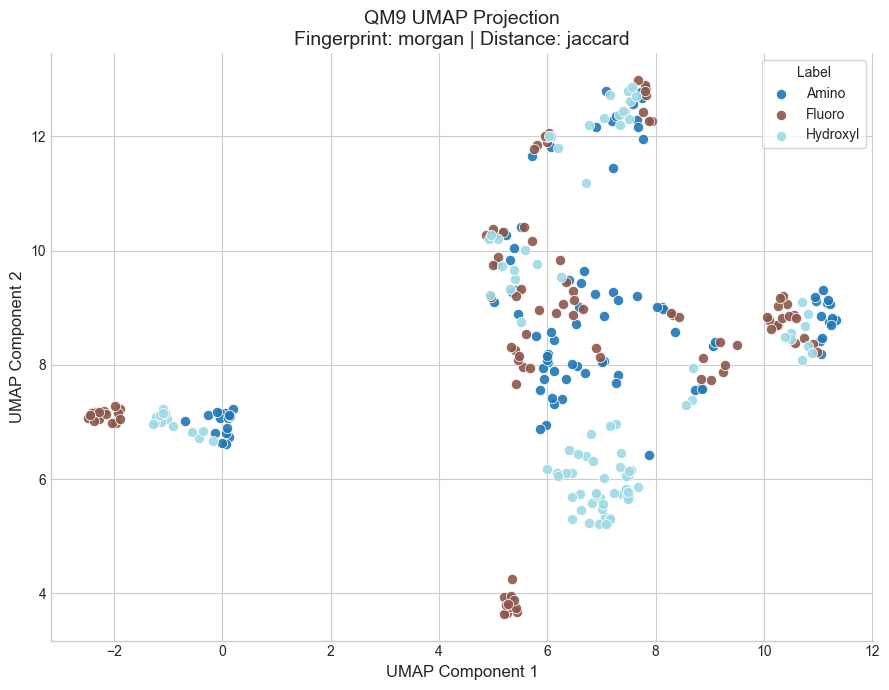

2026-05-15 10:11:05.087 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved UMAP projection plot to figures/qm9/clustering/jaccard/morgan/umap_projection.png


{'coords': array([[ 7.37405109e+00,  5.74087381e+00],
        [ 8.68194389e+00,  7.37691021e+00],
        [ 6.72148561e+00,  1.11824265e+01],
        [ 7.27281523e+00,  6.96709251e+00],
        [ 6.40885687e+00,  6.51103306e+00],
        [ 6.46108627e+00,  6.10335064e+00],
        [ 5.31433487e+00,  9.32006645e+00],
        [ 6.97798014e+00,  5.65269852e+00],
        [ 5.59191275e+00,  1.00064039e+01],
        [ 7.47825813e+00,  5.71303749e+00],
        [ 1.08228083e+01,  8.32225704e+00],
        [-1.02212965e+00,  7.05921888e+00],
        [ 6.96871614e+00,  5.67597961e+00],
        [-4.36446100e-01,  6.72688484e+00],
        [ 7.42782021e+00,  1.24312782e+01],
        [ 7.23577213e+00,  5.74960375e+00],
        [ 7.11990356e+00,  5.25489092e+00],
        [ 7.52217865e+00,  1.26138000e+01],
        [ 6.34324455e+00,  6.10784769e+00],
        [-1.17210519e+00,  7.01690340e+00],
        [ 7.35218430e+00,  6.21631145e+00],
        [-1.13604152e+00,  6.99908924e+00],
        [-1.06529021e+

In [16]:
plot_distance_matrix_projection(dist_matrix_exp, fingerprint="morgan", projection_method='UMAP', labels=df_experiment_balanced["target_group"].to_list(), distance_metric="jaccard")

# Hyphotesis 
If the underlying carbon structure of a molecule is the same it will be able to destingiush by its functional_groups

In [96]:
df['fr_nitro'].top_k(k=10)

fr_nitro
i64
1
1
1
1
1
1
1
1
1


In [108]:
df_hyp2 = df.filter((pl.col("structure_class") == "Aromatic") & (pl.col("generic_scaffold") == "C1CCCC1"))
n = 25
df_hyp2_alcohol = df_hyp2.filter(pl.col("fr_alcohol") > 0).sample(n=n, seed=42)
df_hyp2_amine = df_hyp2.filter(pl.col("fr_nitro") > 0).sample(n=n, seed=42)
df_hyp2_fluoro = df_hyp2.filter(pl.col("num_fluorine") > 0).sample(n=n, seed=42)
df_concat_hyp2 = pl.concat([df_hyp2_alcohol, df_hyp2_amine, df_hyp2_fluoro])
df_concat_hyp2 = df_concat_hyp2.with_columns(target_group = pl.when(pl.col("fr_alcohol") > 0)
    .then(pl.lit("Alcohol"))
    .when(pl.col("fr_nitro") > 0)
    .then(pl.lit("Nitro"))
    .otherwise(pl.lit("Fluoro"))
)

In [109]:
target_group_mapping = {"Alcohol": 0, "Nitro": 1, "Fluoro": 2}

dist_matrix_hyp2 = pairwise_distances(np.array(df_concat_hyp2["morgan_fingerprint"].to_list()), metric="jaccard")
labels_hyp2 = (
    df_concat_hyp2["target_group"]
    .replace(target_group_mapping)
    .to_list()
)

create_chemiscope_viewer(df_concat_hyp2, dist_matrix_hyp2, labels=labels_hyp2, reduction_method="UMAP")

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
2026-05-15 11:58:45.258 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running UMAP dimensionality reduction...
2026-05-15 11:58:45.259 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs v

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden t

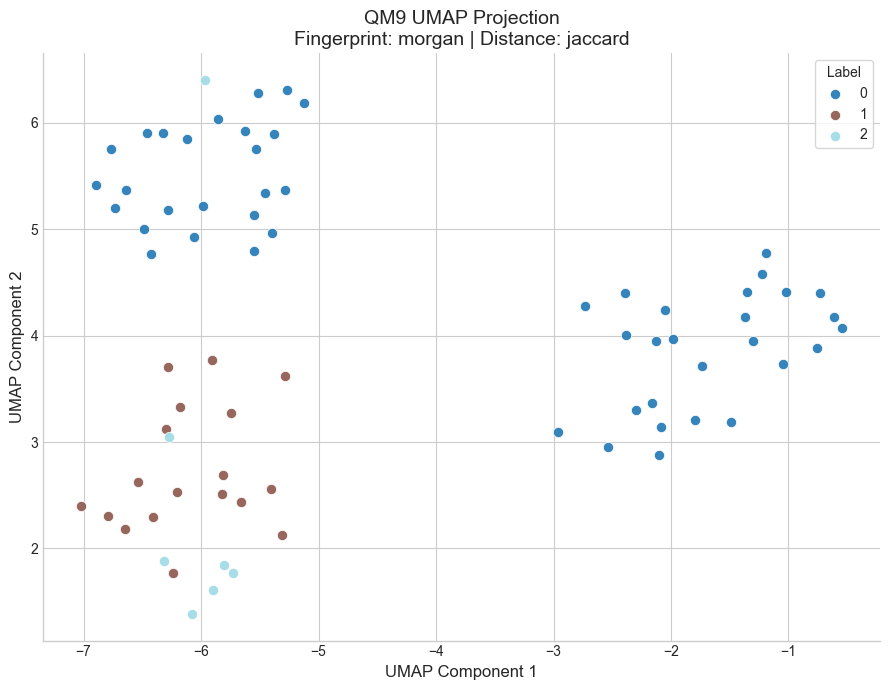

2026-05-15 12:16:56.837 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved UMAP projection plot to figures/qm9/clustering/jaccard/morgan/umap_projection.png


{'coords': array([[-5.8219557 ,  2.5109315 ],
        [-6.533921  ,  2.620806  ],
        [-6.0782313 ,  1.3866713 ],
        [-6.6457596 ,  2.183902  ],
        [-6.7917767 ,  2.300882  ],
        [-6.299102  ,  3.122911  ],
        [-6.2051105 ,  2.5269046 ],
        [-6.2853875 ,  3.7028902 ],
        [-6.270852  ,  3.0470989 ],
        [-6.240565  ,  1.766359  ],
        [-5.307647  ,  2.1295357 ],
        [-5.9055758 ,  3.7667756 ],
        [-6.4105716 ,  2.2915032 ],
        [-5.4029884 ,  2.5627003 ],
        [-6.3193192 ,  1.8852248 ],
        [-5.725891  ,  1.7711068 ],
        [-5.7494397 ,  3.2703645 ],
        [-5.8983464 ,  1.6078864 ],
        [-2.9656446 ,  3.0981014 ],
        [-5.8143044 ,  2.693436  ],
        [-5.2847986 ,  3.6221342 ],
        [-7.0197525 ,  2.3966503 ],
        [-6.1797714 ,  3.3305368 ],
        [-5.805493  ,  1.8418456 ],
        [-5.661893  ,  2.4367552 ],
        [-6.1206913 ,  5.8414006 ],
        [-5.545805  ,  5.1270924 ],
        [-6.321111

In [118]:
# do hieracical clustering on the clusters
agg_clust = AgglomerativeClustering(n_clusters=3, metric='precomputed', linkage='complete')
predicted_labels = agg_clust.fit_predict(dist_matrix_hyp2)
#ari_score = adjusted_rand_score(labels, predicted_labels)
#print(f"ARI Score for Agglomerative Clustering: {ari_score:.4f}")

kmedoids_clust = KMedoids(n_clusters=3, metric='precomputed', random_state=42)
predicted_labels_kmedoids = kmedoids_clust.fit_predict(dist_matrix_hyp2)
#ari_score_kmedoids = adjusted_rand_score(labels, predicted_labels_kmedoids)
#print(f"ARI Score for K-Medoids Clustering: {ari_score_kmedoids:.4f}")

# plot the UMAP projection of the distance matrix
coords = UMAP(metric='precomputed', random_state=42).fit_transform(dist_matrix_hyp2)
plot_distance_matrix_projection(dist_matrix_hyp2, fingerprint="morgan", projection_method='UMAP', labels=predicted_labels, distance_metric="jaccard")

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


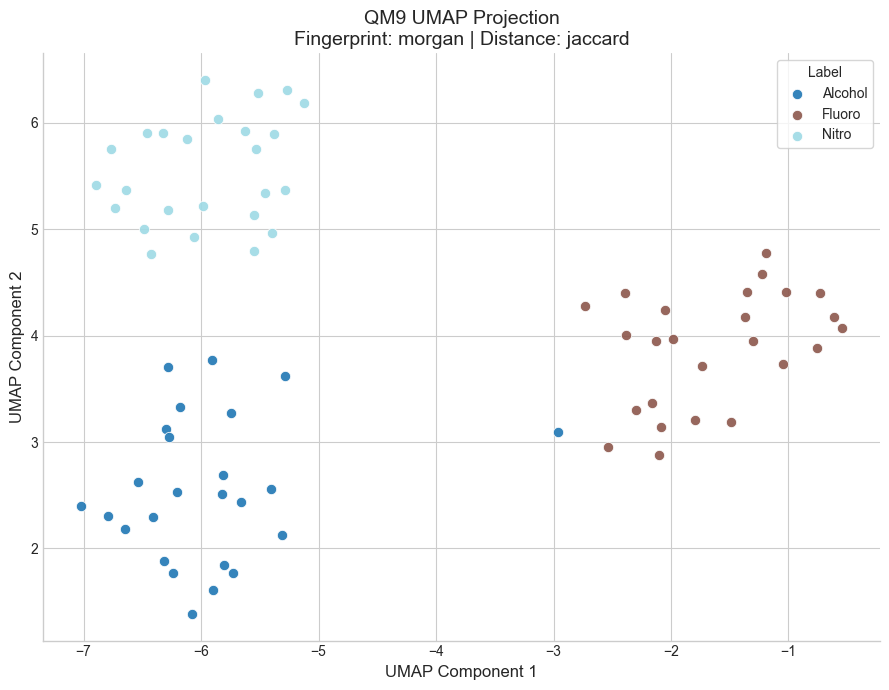

2026-05-15 11:58:49.659 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved UMAP projection plot to figures/qm9/clustering/jaccard/morgan/umap_projection.png


{'coords': array([[-5.8219557 ,  2.5109315 ],
        [-6.533921  ,  2.620806  ],
        [-6.0782313 ,  1.3866713 ],
        [-6.6457596 ,  2.183902  ],
        [-6.7917767 ,  2.300882  ],
        [-6.299102  ,  3.122911  ],
        [-6.2051105 ,  2.5269046 ],
        [-6.2853875 ,  3.7028902 ],
        [-6.270852  ,  3.0470989 ],
        [-6.240565  ,  1.766359  ],
        [-5.307647  ,  2.1295357 ],
        [-5.9055758 ,  3.7667756 ],
        [-6.4105716 ,  2.2915032 ],
        [-5.4029884 ,  2.5627003 ],
        [-6.3193192 ,  1.8852248 ],
        [-5.725891  ,  1.7711068 ],
        [-5.7494397 ,  3.2703645 ],
        [-5.8983464 ,  1.6078864 ],
        [-2.9656446 ,  3.0981014 ],
        [-5.8143044 ,  2.693436  ],
        [-5.2847986 ,  3.6221342 ],
        [-7.0197525 ,  2.3966503 ],
        [-6.1797714 ,  3.3305368 ],
        [-5.805493  ,  1.8418456 ],
        [-5.661893  ,  2.4367552 ],
        [-6.1206913 ,  5.8414006 ],
        [-5.545805  ,  5.1270924 ],
        [-6.321111

In [110]:
plot_distance_matrix_projection(dist_matrix_hyp2, fingerprint="morgan", projection_method='UMAP', labels=df_concat_hyp2["target_group"].to_list(), distance_metric="jaccard")